# Classification of Pet's Real-Life Images

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

Now it's time to deal with more challenging task - classification of the original [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Let's start by loading and visualizing the dataset.

In [ ]:
!http_proxy="http://127.0.0.1:7890" https_proxy="http://127.0.0.1:7890" wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!tar xfz images.tar.gz
!rm images.tar.gz

We will define generic function to display a series of images from a list:

In [28]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

You can see that all images are located in one directory called `images`, and their name contains the name of the class (breed):

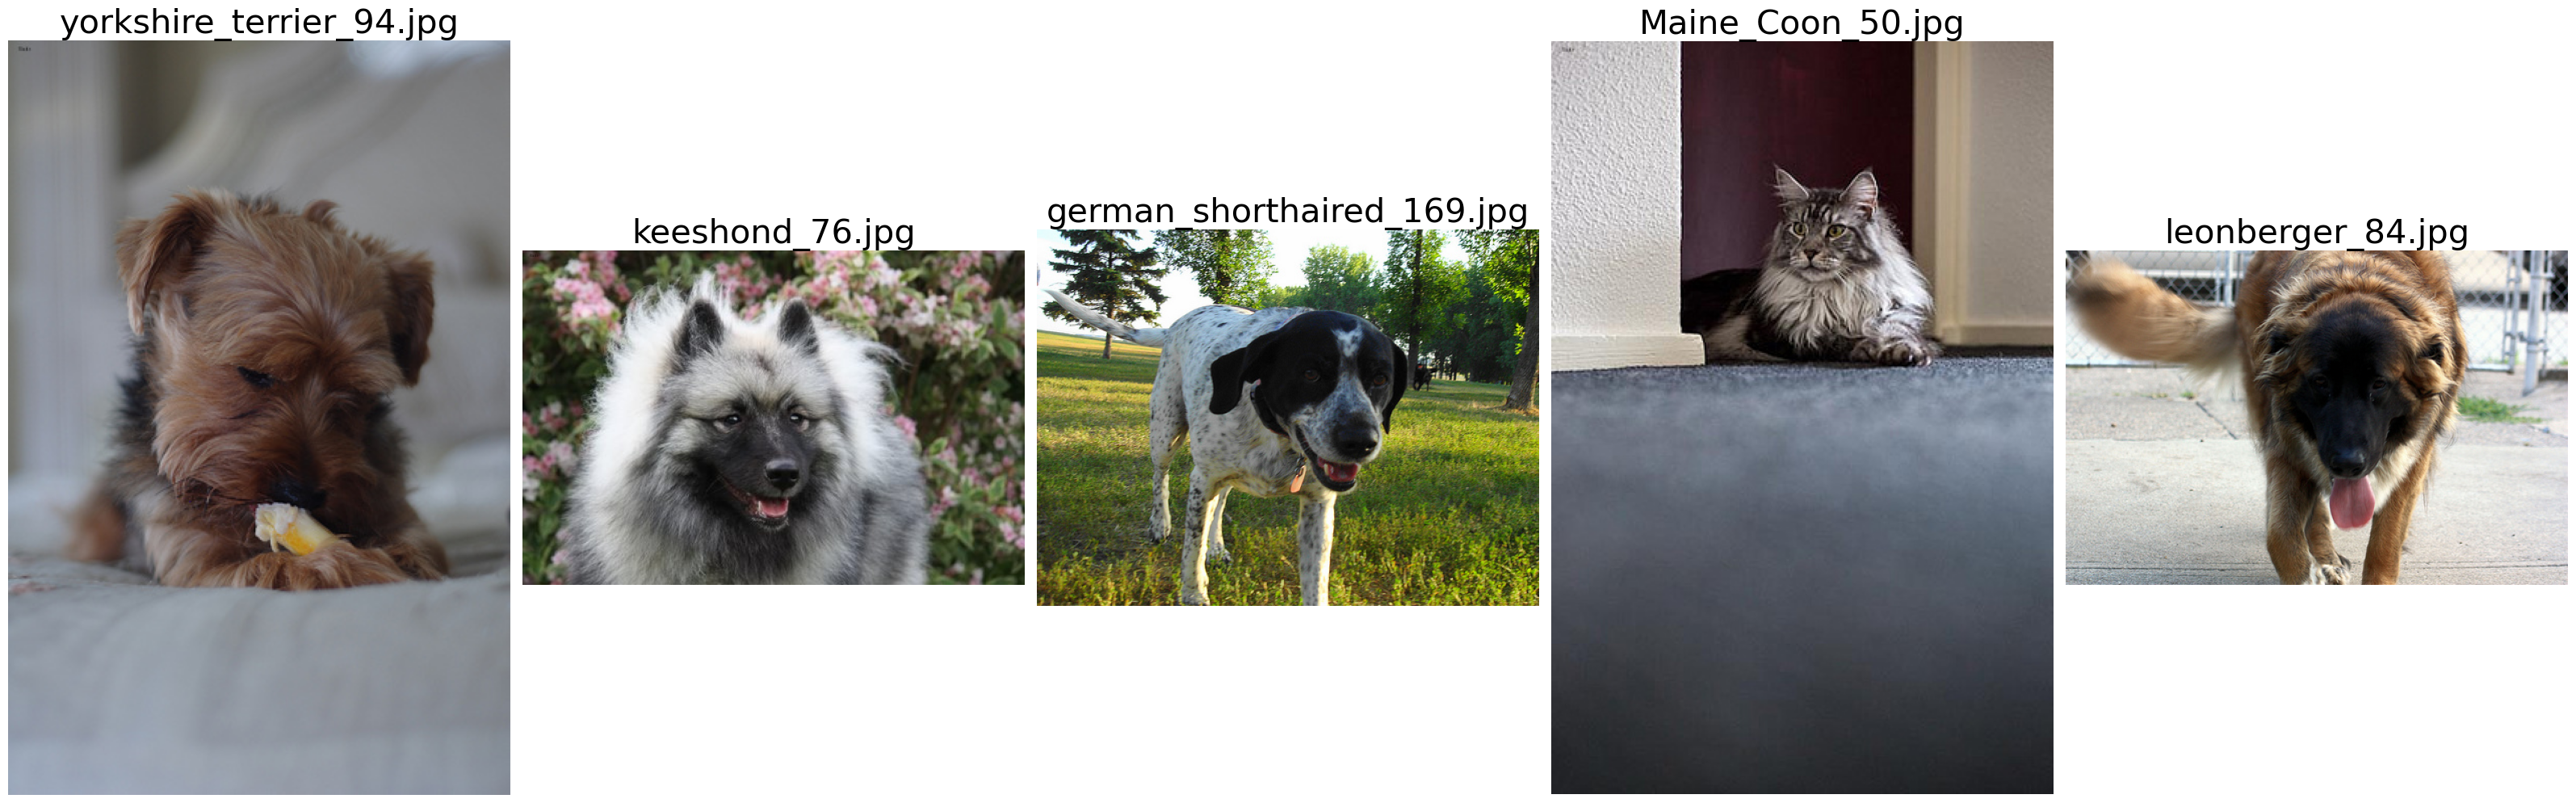

In [29]:
fnames = os.listdir('images')[:5]
display_images([Image.open(os.path.join('images',x)) for x in fnames],titles=fnames,fontsize=30)

To simplify classification and use the same approach to loading images as in the previous part, let's sort all images into corresponding directories:

In [30]:
for fn in os.listdir('images'):
    cls = fn[:fn.rfind('_')].lower()
    os.makedirs(os.path.join('images',cls),exist_ok=True)
    os.replace(os.path.join('images',fn),os.path.join('images',cls,fn))

Let's also define the number of classes in our dataset:

In [31]:
num_classes = len(os.listdir('images'))
num_classes

37

## Preparing dataset for Deep Learning

To start training our neural network, we need to convert all images to tensors, and also create tensors corresponding to labels (class numbers). Most neural network frameworks contain simple tools for dealing with images:
* In Tensorflow, use `tf.keras.preprocessing.image_dataset_from_directory`
* In PyTorch, use `torchvision.datasets.ImageFolder`

As you have seen from the pictures above, all of them are close to square image ratio, so we need to resize all images to square size. Also, we can organize images in minibatches.

In [41]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from PIL import ImageFile

# Handle truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Check GPU availability
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("CUDA not available, using CPU")

print(f'Device: {device}')

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transform - no augmentation
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets with different transforms
train_dataset = torchvision.datasets.ImageFolder('images', transform=train_transform)
val_dataset = torchvision.datasets.ImageFolder('images', transform=val_transform)

print(f'Dataset size: {len(train_dataset)} images')
print(f'Number of classes: {len(train_dataset.classes)}')

# Create train/test split using same indices
import numpy as np
from torch.utils.data import Subset

indices = list(range(len(train_dataset)))
np.random.seed(42)
np.random.shuffle(indices)
train_size = int(0.8 * len(train_dataset))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

trainset = Subset(train_dataset, train_indices)
testset = Subset(val_dataset, test_indices)

print(f'Training set size: {len(trainset)}')
print(f'Test set size: {len(testset)}')

GPU: NVIDIA GeForce RTX 3090
Device: cuda
Dataset size: 7390 images
Number of classes: 37
Training set size: 5912
Test set size: 1478


Now we need to separate dataset into train and test portions:

In [42]:
# The dataset split is now done in the earlier cell with transforms
# This cell is no longer needed - trainset and testset are already defined
print(f'Training set size: {len(trainset)}')
print(f'Test set size: {len(testset)}')

Training set size: 5912
Test set size: 1478


Now define data loaders:

In [43]:
# Define data loaders with GPU optimizations
if device.type == 'cuda':
    batch_size = 64  # Larger batch size for GPU
    num_workers = 2
    pin_memory = True
else:
    batch_size = 32
    num_workers = 0
    pin_memory = False

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory
)

print(f'Batch size: {batch_size}')
print(f'Number of training batches: {len(train_loader)}')
print(f'Number of test batches: {len(test_loader)}')

Batch size: 64
Number of training batches: 93
Number of test batches: 24


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3926706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..1.7511113].


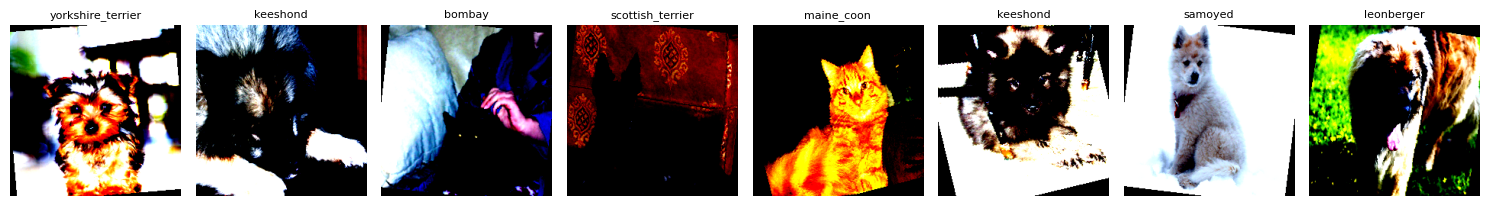

In [44]:
# [OPTIONAL] Plot some samples from the dataset
def display_dataset(dataset, n=10):
    import numpy as np
    fig, ax = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        img, label = dataset[i]
        img_np = img.permute(1, 2, 0).numpy()
        ax[i].imshow(img_np)
        ax[i].axis('off')
        ax[i].set_title(dataset.dataset.classes[label], fontsize=8)
    plt.tight_layout()
    plt.show()

display_dataset(trainset, n=8)

## Define a neural network

For image classification, you should probably define a convolutional neural network with several layers. What to keep an eye for:
* Keep in mind the pyramid architecture, i.e. number of filters should increase as you go deeper
* Do not forget activation functions between layers (ReLU) and Max Pooling
* Final classifier can be with or without hidden layers, but the number of output neurons should be equal to number of classes.

An important thing is to get the activation function on the last layer + loss function right:
* In Tensorflow, you can use `softmax` as the activation, and `sparse_categorical_crossentropy` as loss. The difference between sparse categorical cross-entropy and non-sparse one is that the former expects output as the number of class, and not as one-hot vector.
* In PyTorch, you can have the final layer without activation function, and use `CrossEntropyLoss` loss function. This function applies softmax automatically. 

> **Hint:** In PyTorch, you can use `LazyLinear` layer instead of `Linear`, in order to avoid computing the number of inputs. It only requires one `n_out` parameter, which is number of neurons in the layer, and the dimension of input data is picked up automatically upon first `forward` pass.

In [45]:
# Improved CNN with better architecture
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 224 -> 112
            nn.Dropout2d(0.1),
            
            # Conv Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 112 -> 56
            nn.Dropout2d(0.2),
            
            # Conv Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 56 -> 28
            nn.Dropout2d(0.3),
            
            # Conv Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28 -> 14
            nn.Dropout2d(0.4),
            
            # Global Average Pooling instead of large FC layer
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create model
model = ImprovedCNN(num_classes=len(full_dataset.classes)).to(device)
print(summary(model, (1, 3, 224, 224)))

Layer (type:depth-idx)                   Output Shape              Param #
ImprovedCNN                              [1, 37]                   --
├─Sequential: 1-1                        [1, 512, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-4                       [1, 64, 224, 224]         36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 224, 224]         128
│    └─ReLU: 2-6                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-7                    [1, 64, 112, 112]         --
│    └─Dropout2d: 2-8                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-9                       [1, 128, 112, 112]        73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 112, 112]        256
│    └─ReLU: 2-11                        [1, 128, 112, 112]        --
│

## Train the Neural Network

Now we are ready to train the neural network. During training, please collect accuracy on train and test data on each epoch, and then plot the accuracy to see if there is overfitting.

In [46]:
# Training function with GPU optimizations
def train_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(dataloader), correct / total

def validate(model, dataloader, loss_fn):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(dataloader), correct / total

# Train the model with improvements
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing for regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)  # AdamW with weight decay

# Learning rate scheduler - reduce on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

# Early stopping
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=10)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epochs = 50  # Reduced, with early stopping

print(f"Starting training on {device}...")
best_val_acc = 0

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn)
    val_loss, val_acc = validate(model, test_loader, loss_fn)
    
    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
    
    if device.type == 'cuda':
        mem_used = torch.cuda.max_memory_allocated() / 1024**2
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f} | '
              f'GPU Mem: {mem_used:.0f}MB')
        torch.cuda.reset_peak_memory_stats()
    else:
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')
    
    # Early stopping check
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nTraining completed! Best validation accuracy: {best_val_acc*100:.2f}%")

Starting training on cuda...


Epoch 1/50: Train Loss: 3.6040, Acc: 0.0416 | Val Loss: 3.5624, Acc: 0.0548 | LR: 0.001000 | GPU Mem: 8900MB
Epoch 2/50: Train Loss: 3.5479, Acc: 0.0563 | Val Loss: 3.4990, Acc: 0.0710 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 3/50: Train Loss: 3.5056, Acc: 0.0670 | Val Loss: 3.4471, Acc: 0.0812 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 4/50: Train Loss: 3.4903, Acc: 0.0675 | Val Loss: 3.4408, Acc: 0.0792 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 5/50: Train Loss: 3.4688, Acc: 0.0790 | Val Loss: 3.4160, Acc: 0.0771 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 6/50: Train Loss: 3.4313, Acc: 0.0831 | Val Loss: 3.3880, Acc: 0.0825 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 7/50: Train Loss: 3.4250, Acc: 0.0851 | Val Loss: 3.3864, Acc: 0.0805 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 8/50: Train Loss: 3.4060, Acc: 0.0891 | Val Loss: 3.3640, Acc: 0.0913 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 9/50: Train Loss: 3.3762, Acc: 0.0934 | Val Loss: 3.3472, Acc: 0.0900 | LR: 0.001000 | GPU Mem: 7381MB
Epoch 10/50: Train 

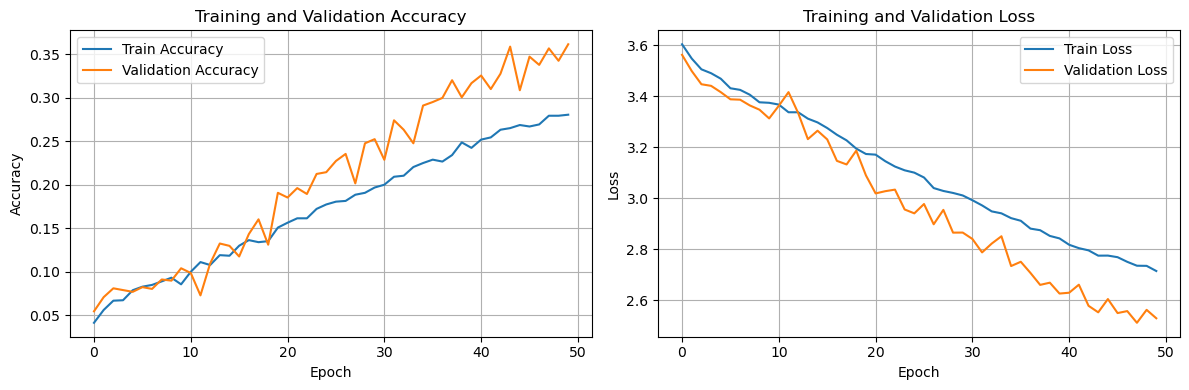

Final Validation Accuracy: 36.13%


In [47]:
# Plot training results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history['train_acc'], label='Train Accuracy')
ax1.plot(history['val_acc'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history['train_loss'], label='Train Loss')
ax2.plot(history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training and Validation Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'Final Validation Accuracy: {history["val_acc"][-1]*100:.2f}%')

Even if you have done everything correctly, you will probably see that the accuracy is quite low.

## Transfer Learning

To improve the accuracy, let's use pre-trained neural network as feature extractor. Feel free to experiment with VGG-16/VGG-19 models, ResNet50, etc.

> Since this training is slower, you may start with training the model for the small number of epochs, eg. 3. You can always resume training to further improve accuracy if needed.

We need to normalize our data differently for transfer learning, thus we will reload the dataset again using different set of transforms:

In [48]:
# LOAD THE DATASET with proper normalization for pre-trained models
# Standard normalization for ImageNet pre-trained models (VGG, ResNet, etc.)
std_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

trans_vgg = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    std_normalize
])

# Reload dataset with VGG transforms
dataset_vgg = torchvision.datasets.ImageFolder('images', transform=trans_vgg)

# Split into train and test
train_size = int(0.8 * len(dataset_vgg))
test_size = len(dataset_vgg) - train_size
trainset_vgg, testset_vgg = torch.utils.data.random_split(
    dataset_vgg, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Use GPU-optimized DataLoader settings
if device.type == 'cuda':
    batch_size_vgg = 32  # VGG uses more memory, so smaller batch
    num_workers = 2
    pin_memory = True
else:
    batch_size_vgg = 16
    num_workers = 0
    pin_memory = False

train_loader_vgg = torch.utils.data.DataLoader(
    trainset_vgg, batch_size=batch_size_vgg, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory
)
test_loader_vgg = torch.utils.data.DataLoader(
    testset_vgg, batch_size=batch_size_vgg, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory
)

print(f'Dataset loaded with VGG normalization')
print(f'Batch size: {batch_size_vgg}')
print(f'Training samples: {len(trainset_vgg)}, Test samples: {len(testset_vgg)}')

Dataset loaded with VGG normalization
Batch size: 32
Training samples: 5912, Test samples: 1478


Let's load the pre-trained network:

In [ ]:
## 方法1（有点慢）
# Load pre-trained VGG16 model
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
print(vgg)



## 方法2  wget https://download.pytorch.org/models/vgg16-397923af.pth 
# # 1. 先实例化一个没有预训练权重的空模型
# vgg = torchvision.models.vgg16()

# # 2. 指定你手动下载的本地权重文件路径
# local_weight_path = './vgg16-397923af.pth' 

# # 3. 加载本地权重到模型中
# vgg.load_state_dict(torch.load(local_weight_path))

# print(vgg)

/tmp/ipykernel_89673/1371059500.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vgg.load_state_dict(torch.load(local_weight_path))


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Now define the classification model for your problem:
* In PyTorch, there is a slot called `classifier`, which you can replace with your own classifier for the desired number of classes.
* In TensorFlow, use VGG network as feature extractor, and build a `Sequential` model with VGG as first layer, and your own classifier on top

In [51]:
# BUILD MODEL for your problem with your own linear layers
# Replace the classifier with a custom one for our number of classes
vgg.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

model_vgg = vgg.to(device)
print(summary(model_vgg, (1, 3, 224, 224)))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 37]                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

Make sure to set all parameters of VGG feature extractor not to be trainable

In [52]:
# MAKE VGG Layers not trainable
# Freeze all the feature extraction layers
for param in model_vgg.features.parameters():
    param.requires_grad = False

# Verify which layers are trainable
trainable_params = sum(p.numel() for p in model_vgg.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_vgg.parameters())
print(f'Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.2f}%)')

Trainable parameters: 104,881,189 / 119,595,877 (87.70%)


Now we can start the training. Be very patient, as training takes a long time, and our train function is not designed to print anything before the end of the epoch.

Starting VGG training on cuda...
Epoch 1/3: Train Loss: 1.9646, Acc: 0.4843 | Val Loss: 0.5639, Acc: 0.8072 | GPU Mem: 3106MB
Epoch 2/3: Train Loss: 0.9741, Acc: 0.7216 | Val Loss: 0.5578, Acc: 0.8106 | GPU Mem: 2908MB
Epoch 3/3: Train Loss: 0.8105, Acc: 0.7859 | Val Loss: 0.5789, Acc: 0.8363 | GPU Mem: 2908MB
Training completed!


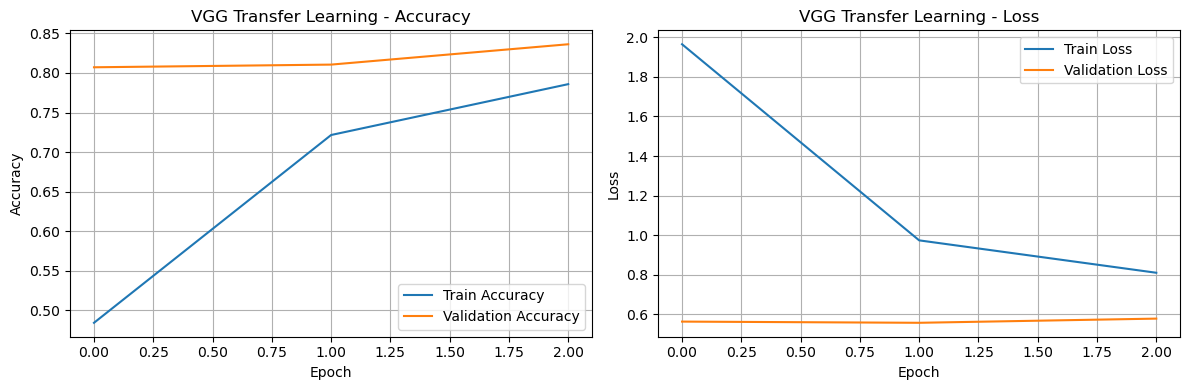


Final Validation Accuracy: 83.63%


In [53]:
# TRAIN THE MODEL with GPU optimizations
optimizer_vgg = torch.optim.Adam(model_vgg.classifier.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

history_vgg = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epochs = 3

print(f"Starting VGG training on {device}...")
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_vgg, train_loader_vgg, optimizer_vgg, loss_fn)
    val_loss, val_acc = validate(model_vgg, test_loader_vgg, loss_fn)
    
    history_vgg['train_loss'].append(train_loss)
    history_vgg['train_acc'].append(train_acc)
    history_vgg['val_loss'].append(val_loss)
    history_vgg['val_acc'].append(val_acc)
    
    # Show GPU memory usage
    if device.type == 'cuda':
        mem_used = torch.cuda.max_memory_allocated() / 1024**2
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | '
              f'GPU Mem: {mem_used:.0f}MB')
        torch.cuda.reset_peak_memory_stats()
    else:
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

print("Training completed!")

# Plot training results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_vgg['train_acc'], label='Train Accuracy')
ax1.plot(history_vgg['val_acc'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('VGG Transfer Learning - Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_vgg['train_loss'], label='Train Loss')
ax2.plot(history_vgg['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('VGG Transfer Learning - Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'\nFinal Validation Accuracy: {history_vgg["val_acc"][-1]*100:.2f}%')

It seems much better now!

## Optional: Calculate Top 3 Accuracy

We can also computer Top 3 accuracy using the same code as in the previous exercise.


In [54]:
# CALCULATE TOP-3 Accuracy of the model
def top_k_accuracy(model, dataloader, k=3):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Get top-k predictions
            _, top_k_preds = outputs.topk(k, dim=1)
            
            # Check if true label is in top-k predictions
            correct += top_k_preds.eq(labels.view(-1, 1).expand_as(top_k_preds)).sum().item()
            total += labels.size(0)
    
    return correct / total

# Calculate Top-1 and Top-3 accuracy
top1_acc = top_k_accuracy(model_vgg, test_loader_vgg, k=1)
top3_acc = top_k_accuracy(model_vgg, test_loader_vgg, k=3)

print(f'Top-1 Accuracy: {top1_acc*100:.2f}%')
print(f'Top-3 Accuracy: {top3_acc*100:.2f}%')

# Compare with simple CNN
print(f'\nComparison:')
print(f'Simple CNN Top-1 Accuracy: {history["val_acc"][-1]*100:.2f}%')
print(f'VGG Transfer Learning Top-1 Accuracy: {top1_acc*100:.2f}%')
print(f'VGG Transfer Learning Top-3 Accuracy: {top3_acc*100:.2f}%')

Top-1 Accuracy: 83.63%
Top-3 Accuracy: 97.09%

Comparison:
Simple CNN Top-1 Accuracy: 36.13%
VGG Transfer Learning Top-1 Accuracy: 83.63%
VGG Transfer Learning Top-3 Accuracy: 97.09%
